# Q2
### Tasks
#### 1

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset
df_customers = pd.read_csv('q2_customers.csv')

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_customers)

# Convert back to dataframe for easier inspection if needed
df_scaled = pd.DataFrame(scaled_features, columns=df_customers.columns)

print("Data scaled successfully. Preview of scaled data:")
df_scaled.head()

Data scaled successfully. Preview of scaled data:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


#### 2

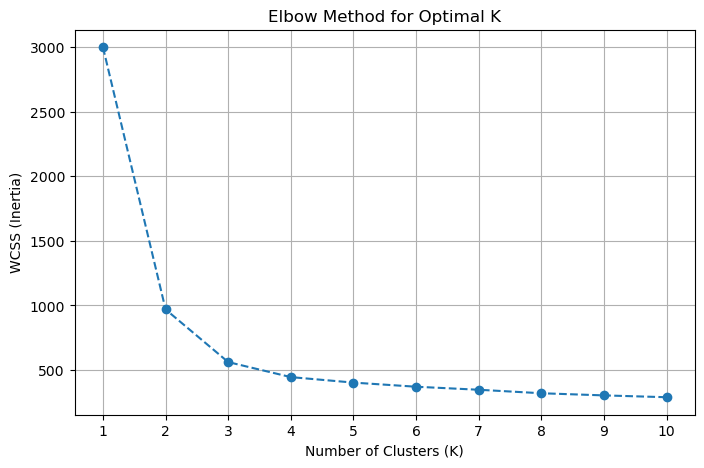

In [8]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

#### 3

In [11]:
# Assuming optimal K=4 based on a typical elbow result
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_customers['cluster'] = kmeans_final.fit_predict(scaled_features)

# Print cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_), 
    columns=df_customers.columns[:-1]
)
print("Cluster Centroids (Original Scale):")
centroids

Cluster Centroids (Original Scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


#### 4

In [15]:
# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

# Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Feature Loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=df_customers.columns[:-1]
)
print("\nFeature Loadings (Components):")
loadings

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings (Components):


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479
